# Window Functions Utilities

## Theory

### Why Windowing?

- **Spectral Leakage:** When you compute the FFT of a finite signal segment, it’s as if the signal was abruptly cut off (multiplied by a rectangular window). This can spread (“leak”) energy into nearby frequencies.
- **Solution:** Taper the signal smoothly to zero at the edges with a window function (Hann, Hamming, Blackman, etc.).
- **In DSP/Sonar:** Windowing is standard for FFTs, spectrograms, and filter design.

### Common Window Types

- **Rectangular:** No tapering (classic “boxcar” window)
- **Hann:** Cosine-shaped, good for general FFT analysis
- **Hamming:** Similar to Hann but slightly less side lobe leakage
- **Blackman:** More aggressive side lobe reduction

---


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window

def apply_window(signal, window_type='hann'):
    """Apply a window function to the signal."""
    N = len(signal)
    window = get_window(window_type, N)
    return signal * window

def plot_window(window_type, N=256):
    window = get_window(window_type, N)
    plt.figure(figsize=(7,3))
    plt.plot(window)
    plt.title(f'{window_type.title()} Window (N={N})')
    plt.xlabel('Sample')
    plt.ylabel('Amplitude')
    plt.tight_layout()
    plt.show()

def plot_window_spectrum(window_type, N=256, fs=1.0):
    window = get_window(window_type, N)
    W = np.abs(np.fft.fft(window, 4096))
    freqs = np.fft.fftfreq(len(W), d=1/fs)
    plt.figure(figsize=(7,3))
    plt.plot(np.fft.fftshift(freqs), np.fft.fftshift(20*np.log10(W/W.max() + 1e-10)))
    plt.title(f'{window_type.title()} Window Frequency Response')
    plt.xlabel('Frequency')
    plt.ylabel('Magnitude (dB)')
    plt.tight_layout()
    plt.show()


### Window Function Demos

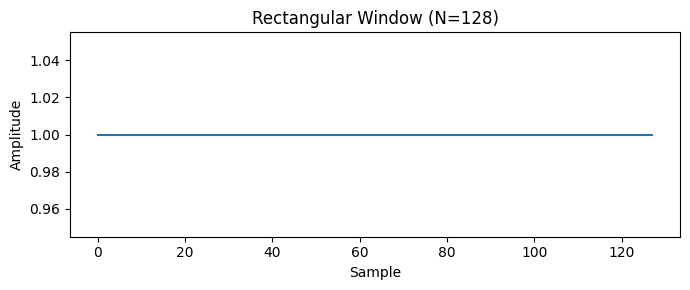

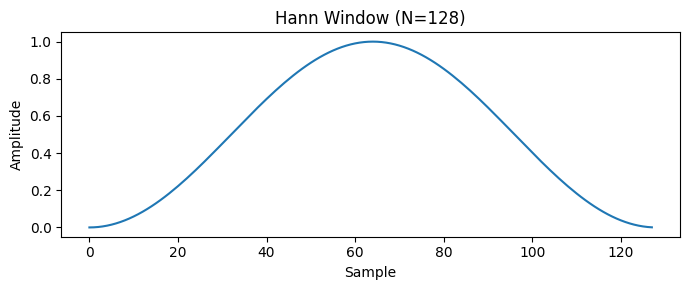

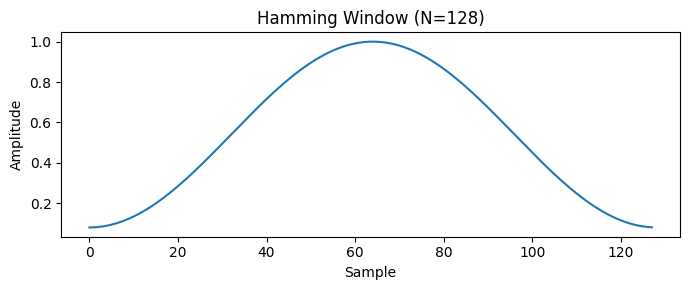

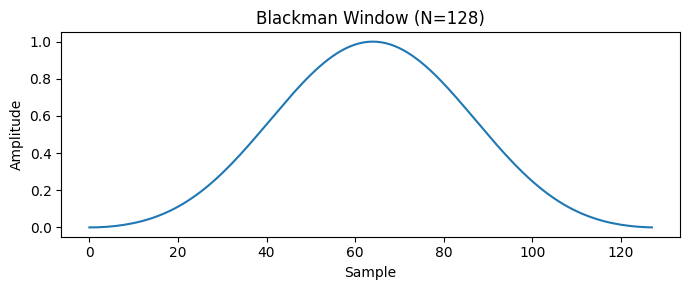

In [2]:
for win in ['rectangular', 'hann', 'hamming', 'blackman']:
    plot_window(win, N=128)


### Window Frequency Response Demos

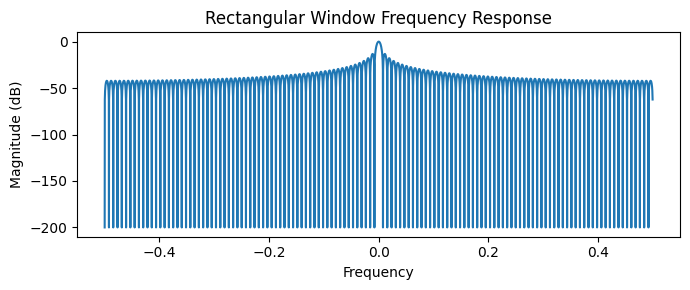

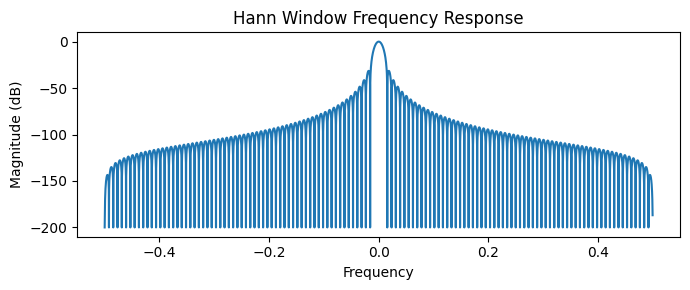

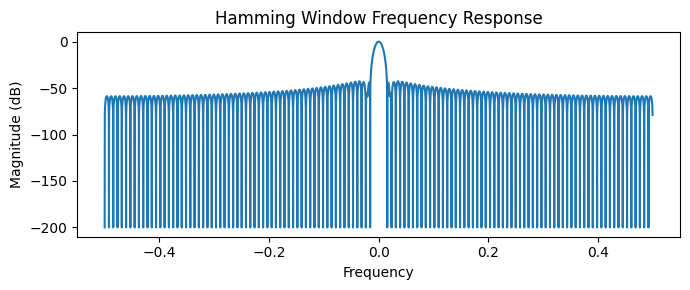

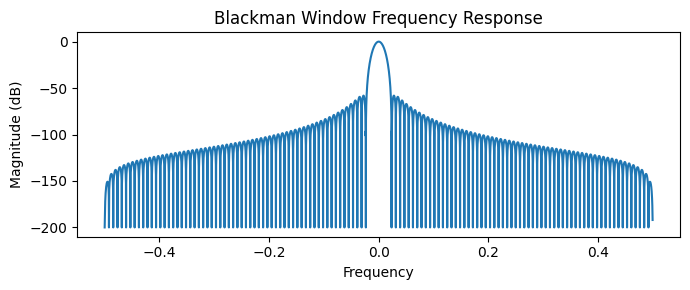

In [3]:
for win in ['rectangular', 'hann', 'hamming', 'blackman']:
    plot_window_spectrum(win, N=128)


### Effect of Windowing on FFT Demo

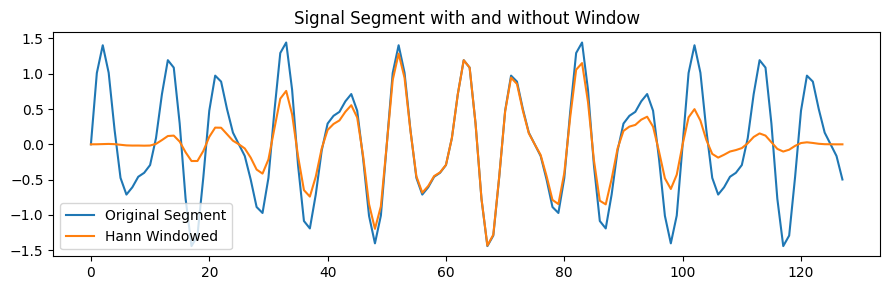

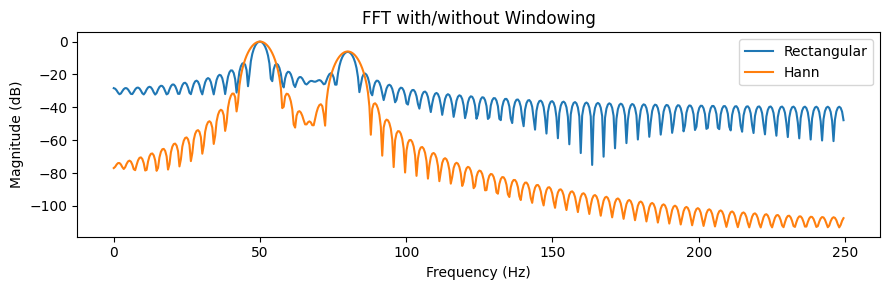

In [4]:
fs = 500
t = np.linspace(0, 1, fs, endpoint=False)
sig = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*80*t)
N = 128
sig_win = sig[:N]
sig_hann = apply_window(sig_win, 'hann')

plt.figure(figsize=(9,3))
plt.plot(sig_win, label='Original Segment')
plt.plot(sig_hann, label='Hann Windowed')
plt.title('Signal Segment with and without Window')
plt.legend()
plt.tight_layout()
plt.show()

# FFT comparison
fft_orig = np.abs(np.fft.fft(sig_win, 1024))
fft_hann = np.abs(np.fft.fft(sig_hann, 1024))
freqs = np.fft.fftfreq(1024, d=1/fs)

plt.figure(figsize=(9,3))
plt.plot(freqs[:512], 20*np.log10(fft_orig[:512]/fft_orig.max()+1e-10), label='Rectangular')
plt.plot(freqs[:512], 20*np.log10(fft_hann[:512]/fft_hann.max()+1e-10), label='Hann')
plt.title('FFT with/without Windowing')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.tight_layout()
plt.show()


---
## Usage Tips
- Always window signals for FFT/spectral analysis unless you have a perfect periodic segment.
- Try different windows and lengths; Hann and Hamming are good defaults for DSP.

**Add these tools to all your DSP and sonar analysis for reliable, interpretable results!**
